     [Mean] Complete Regression Metrics (Sorted by R2)    
            Feature  R2_Score      P_Value  Coefficient
              B4/B5  0.518654 2.876222e-11   -29.005173
    (B4-B5)/(B4+B5)  0.512312 4.312398e-11   -52.190751
              B5/B4  0.499432 9.665425e-11    22.371433
              B2/B5  0.454117 1.420742e-09   -14.421551
    (B2-B5)/(B2+B5)  0.437476 3.612934e-09   -32.633550
    (B3-B5)/(B3+B5)  0.434671 4.217312e-09   -35.888184
              B5/B3  0.432319 4.798828e-09    25.192577
              B3/B5  0.419873 9.426057e-09   -10.320133
              B5/B2  0.401321 2.514268e-08    16.213931
    (B2-B7)/(B2+B7)  0.168902 8.202699e-04   -17.931643
    (B2-B6)/(B2+B6)  0.132174 3.402702e-03   -15.141692
              B2/B4  0.131196 3.532545e-03   -14.298635
    (B2-B4)/(B2+B4)  0.118056 5.832599e-03   -32.141861
              B2/B7  0.113644 6.897762e-03    -3.535817
              B7/B2  0.112152 7.300220e-03     9.651136
              B4/B2  0.108568 8.364146e-03   

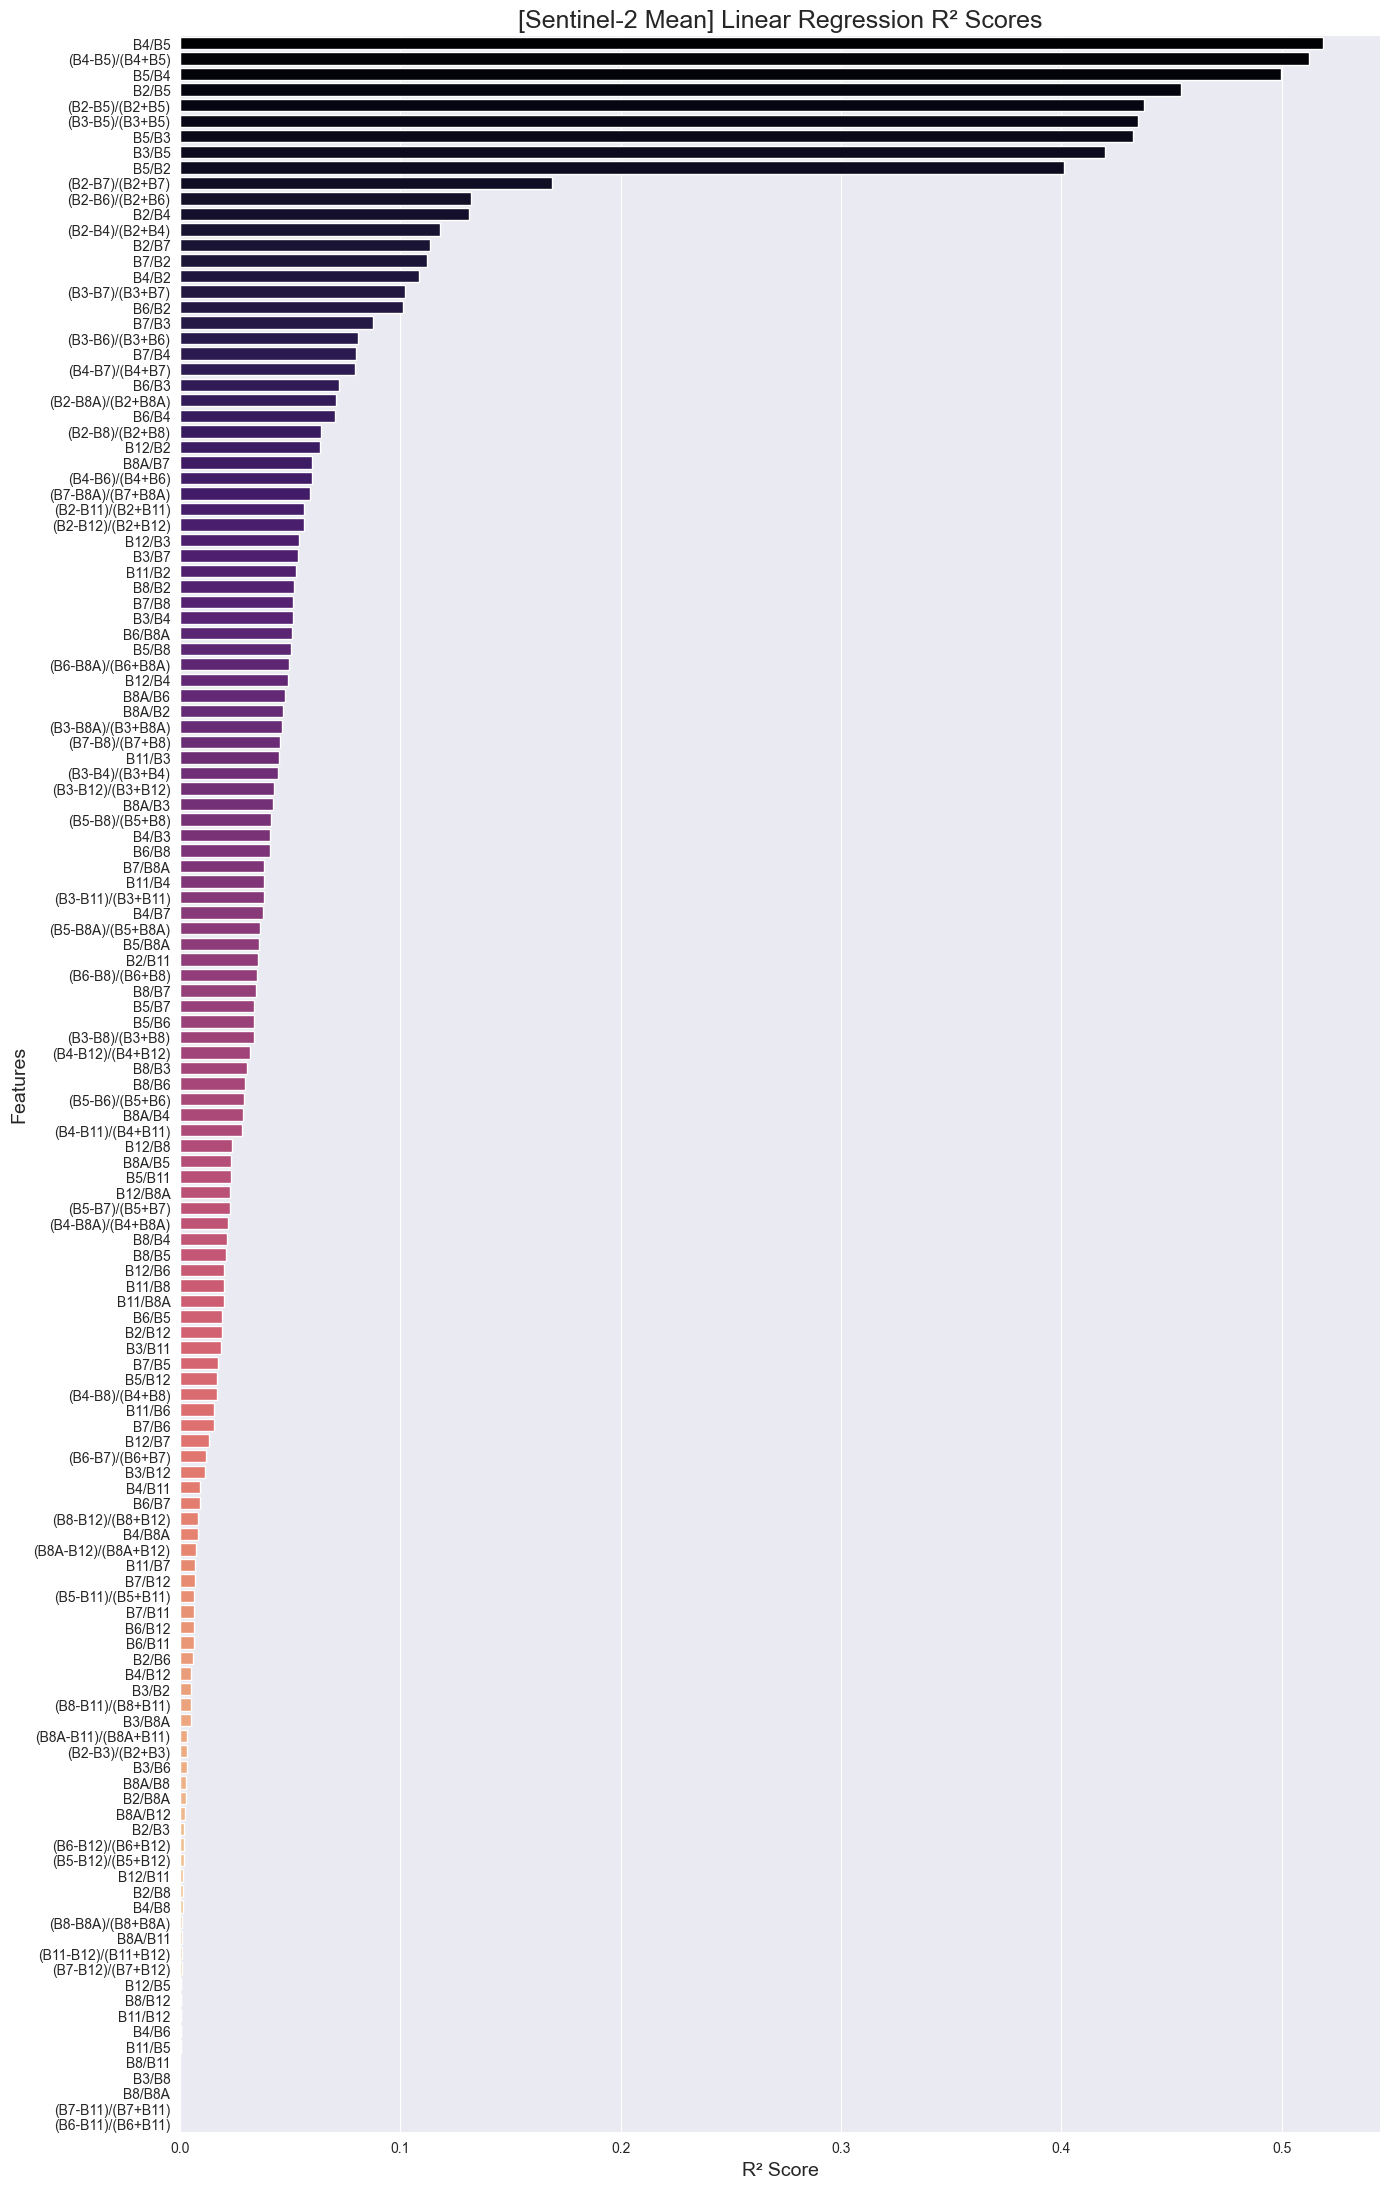

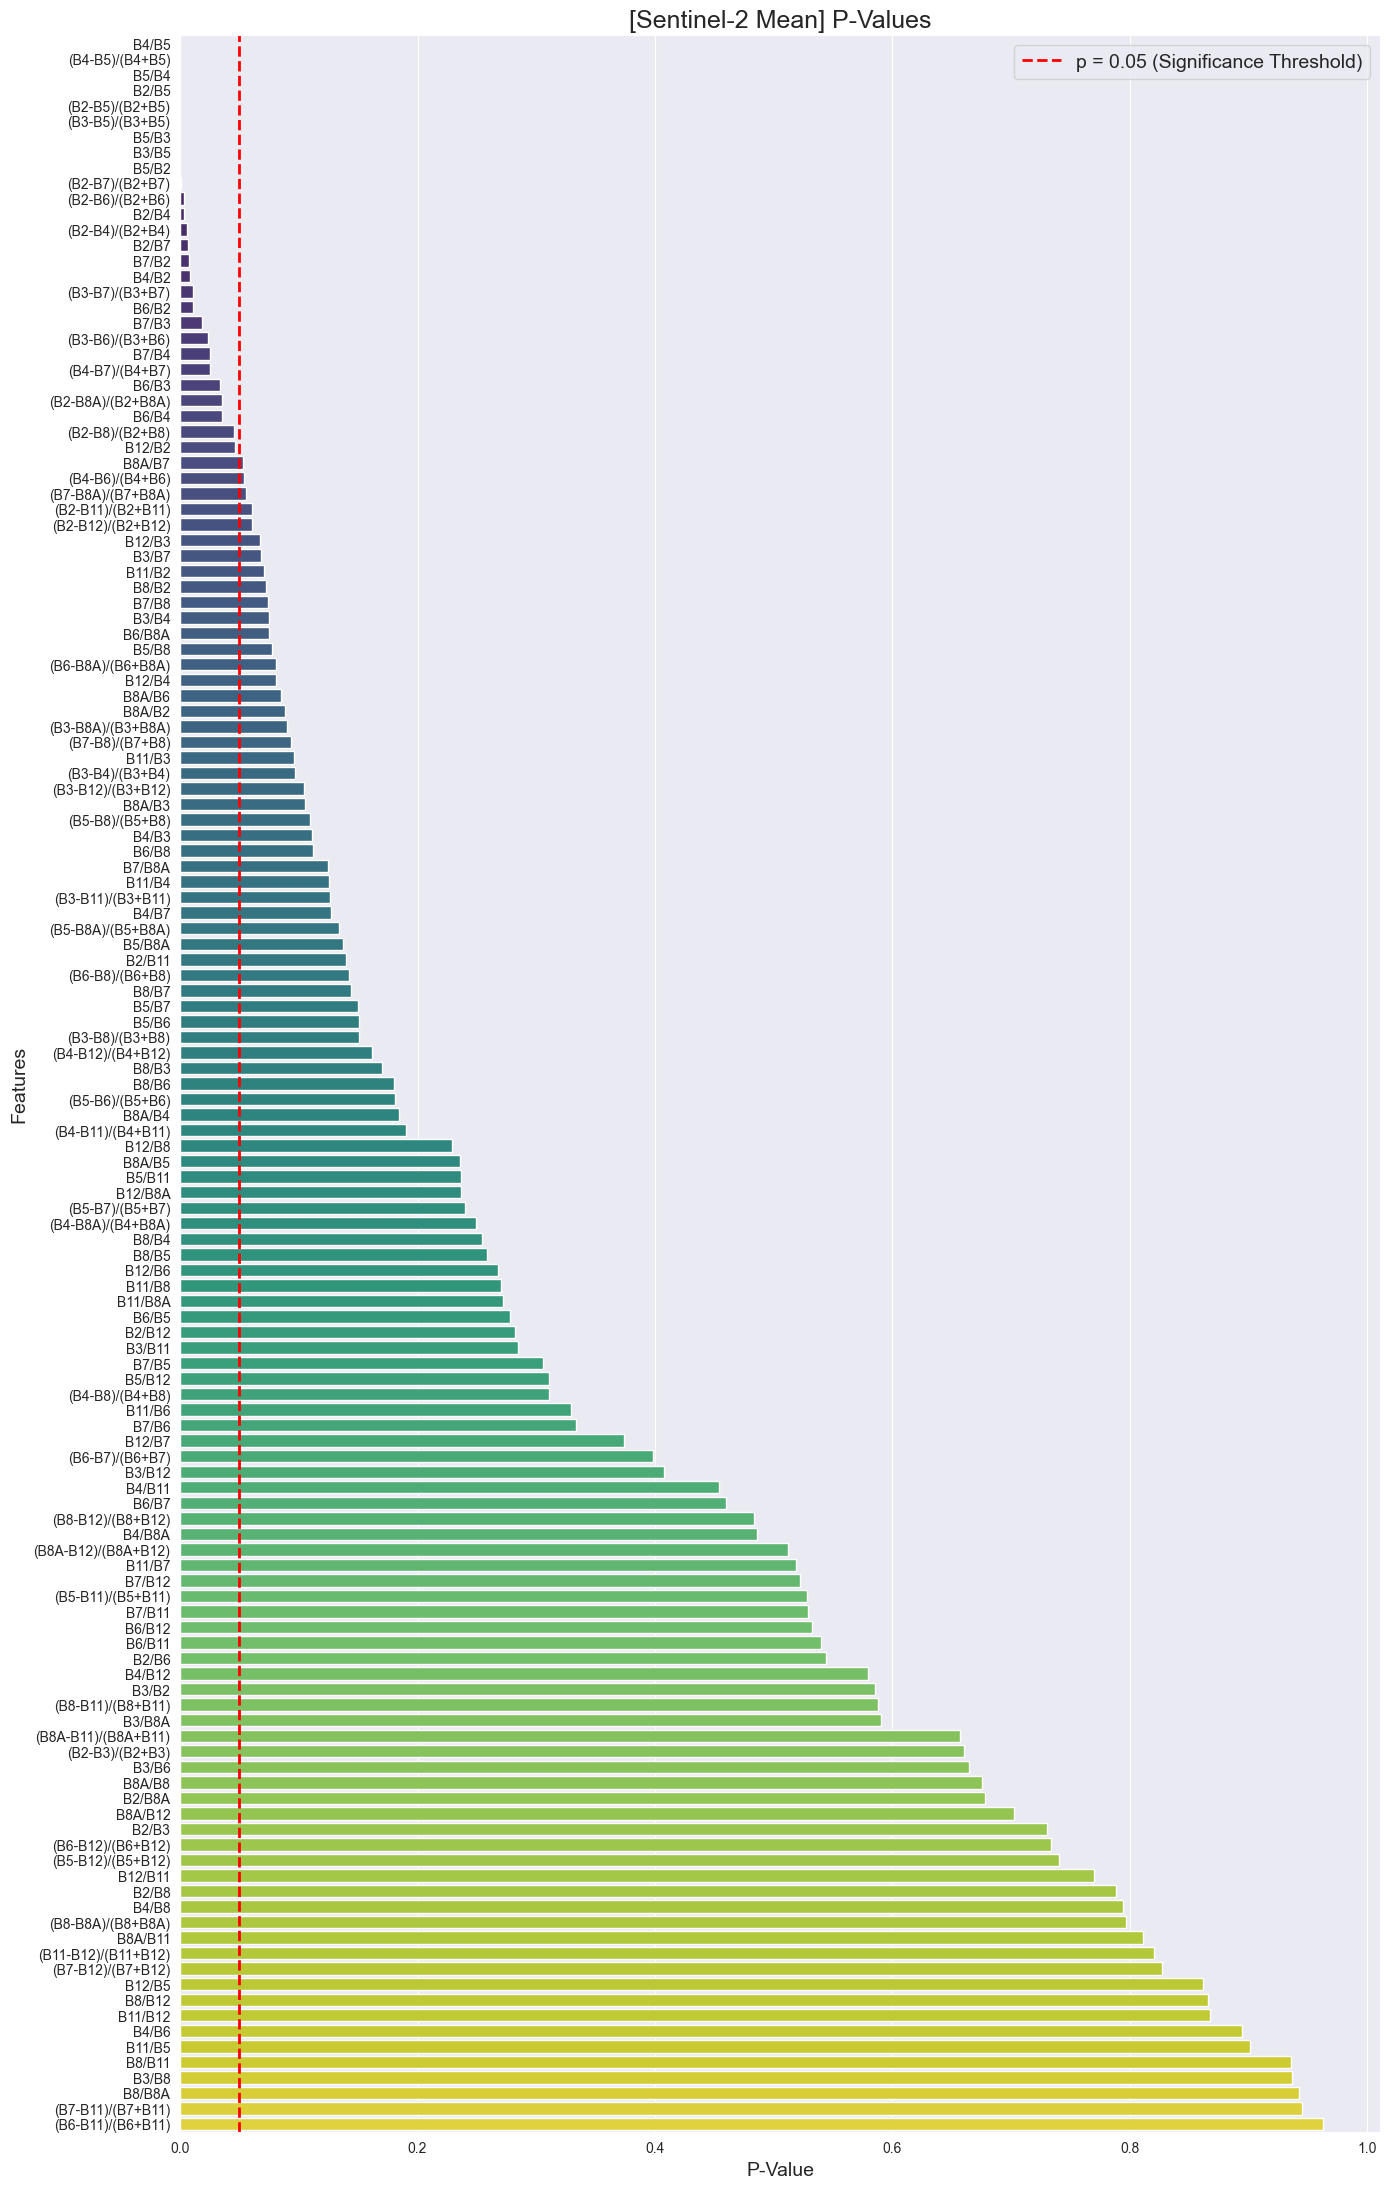

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Load Data ---
file_path = "Sentinel2_2024_Combinations(Mean_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
y = data[target_col]

# --- 3. Calculate Regression Metrics (P-Values, R2) ---
results = []
for col in feature_cols:
    X = data[col]
    X = sm.add_constant(X) # Add y-intercept
    model = sm.OLS(y, X).fit()

    results.append({
        'Feature': col,
        'R2_Score': model.rsquared,
        'P_Value': model.pvalues[col],
        'Coefficient': model.params[col]
    })

# Combine into one DataFrame and sort by highest R2 Score
results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("     [Mean] Complete Regression Metrics (Sorted by R2)    ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting ---

# Plot 1: R2 Score
plt.figure(figsize=(14, 22))
sns.barplot(x='R2_Score', y='Feature', data=results_df, palette='magma', hue='Feature', legend=False)
plt.title('[Sentinel-2 Mean] Linear Regression R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: P-Values
plt.figure(figsize=(14, 22))
# Sort by lowest p-value (most statistically significant)
pval_sorted = results_df.sort_values(by='P_Value', ascending=True)
sns.barplot(x='P_Value', y='Feature', data=pval_sorted, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (Significance Threshold)')
plt.title('[Sentinel-2 Mean] P-Values', fontsize=18)
plt.xlabel('P-Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Export to Excel
results_df.to_excel("Sentinel_Mean_Regression_Results.xlsx", index=False)

    [Median] Complete Regression Metrics (Sorted by R2)   
            Feature  R2_Score      P_Value  Coefficient
    (B4-B5)/(B4+B5)  0.559401 1.869296e-12   -54.226932
              B4/B5  0.557667 2.110408e-12   -29.934489
              B5/B4  0.553065 2.905056e-12    23.323775
              B2/B5  0.460101 1.008900e-09   -13.970007
    (B2-B5)/(B2+B5)  0.442858 2.679407e-09   -31.795326
    (B3-B5)/(B3+B5)  0.417310 1.081322e-08   -33.810700
              B3/B5  0.411186 1.497703e-08    -9.956701
              B5/B3  0.407653 1.804717e-08    23.135302
              B5/B2  0.402378 2.379504e-08    15.794093
    (B2-B7)/(B2+B7)  0.144676 2.104586e-03   -15.965835
              B2/B4  0.114962 6.560984e-03   -12.056520
    (B2-B6)/(B2+B6)  0.107858 8.592356e-03   -12.923447
              B2/B7  0.106614 9.007551e-03    -3.419641
    (B2-B4)/(B2+B4)  0.098714 1.215180e-02   -26.832019
              B4/B2  0.084746 2.062715e-02    14.219563
    (B3-B7)/(B3+B7)  0.081572 2.326582e-02   

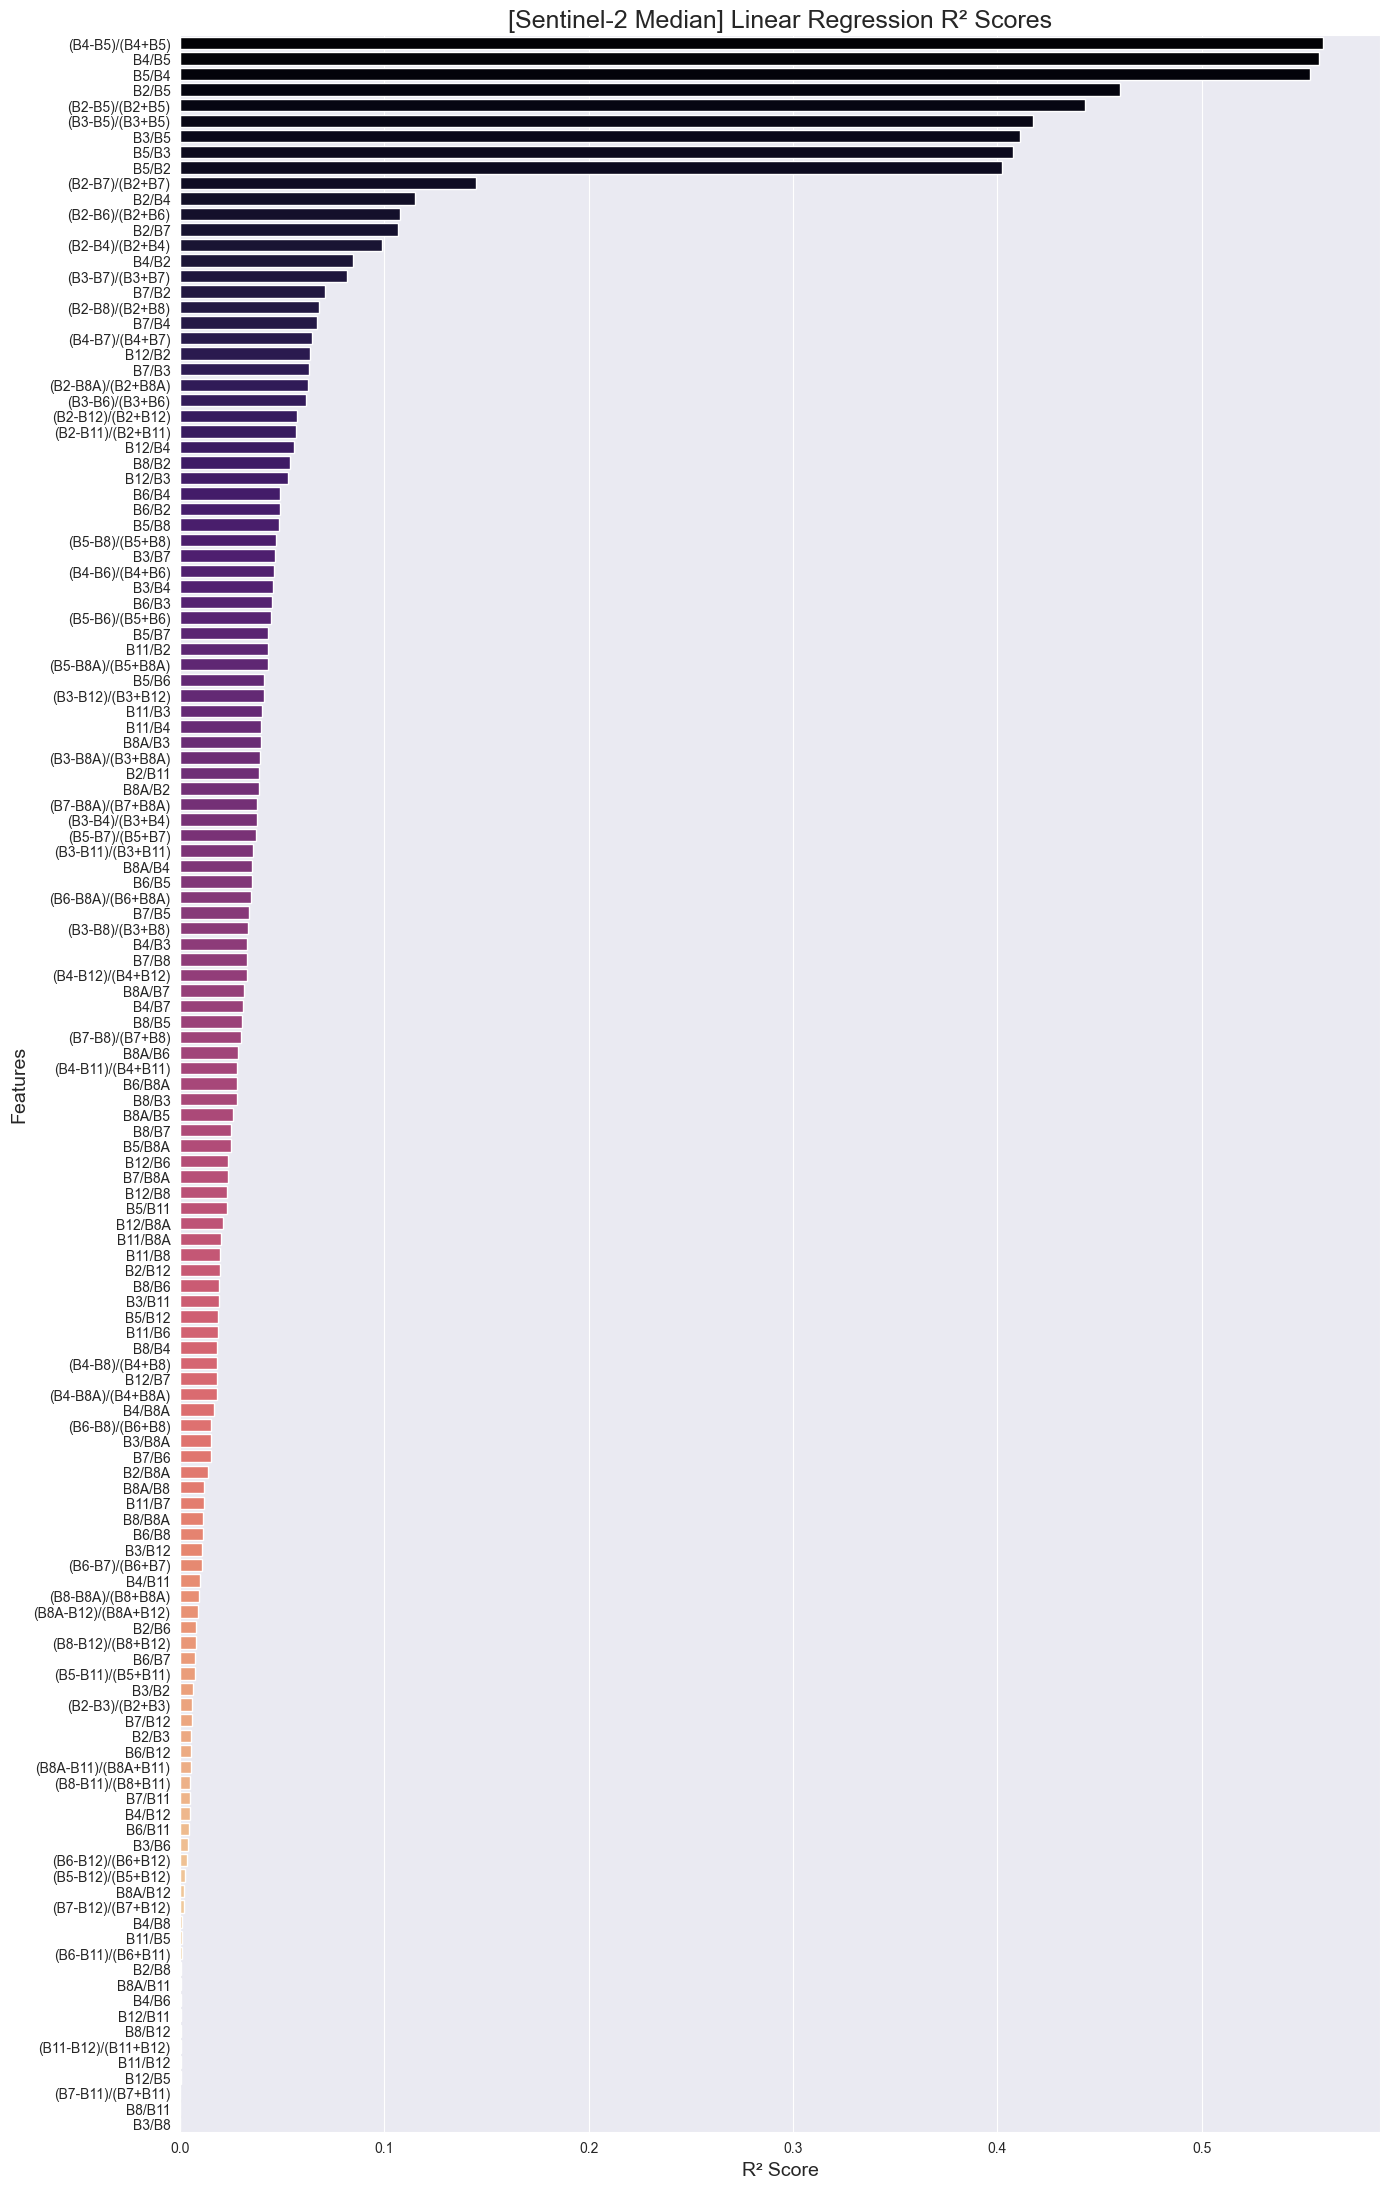

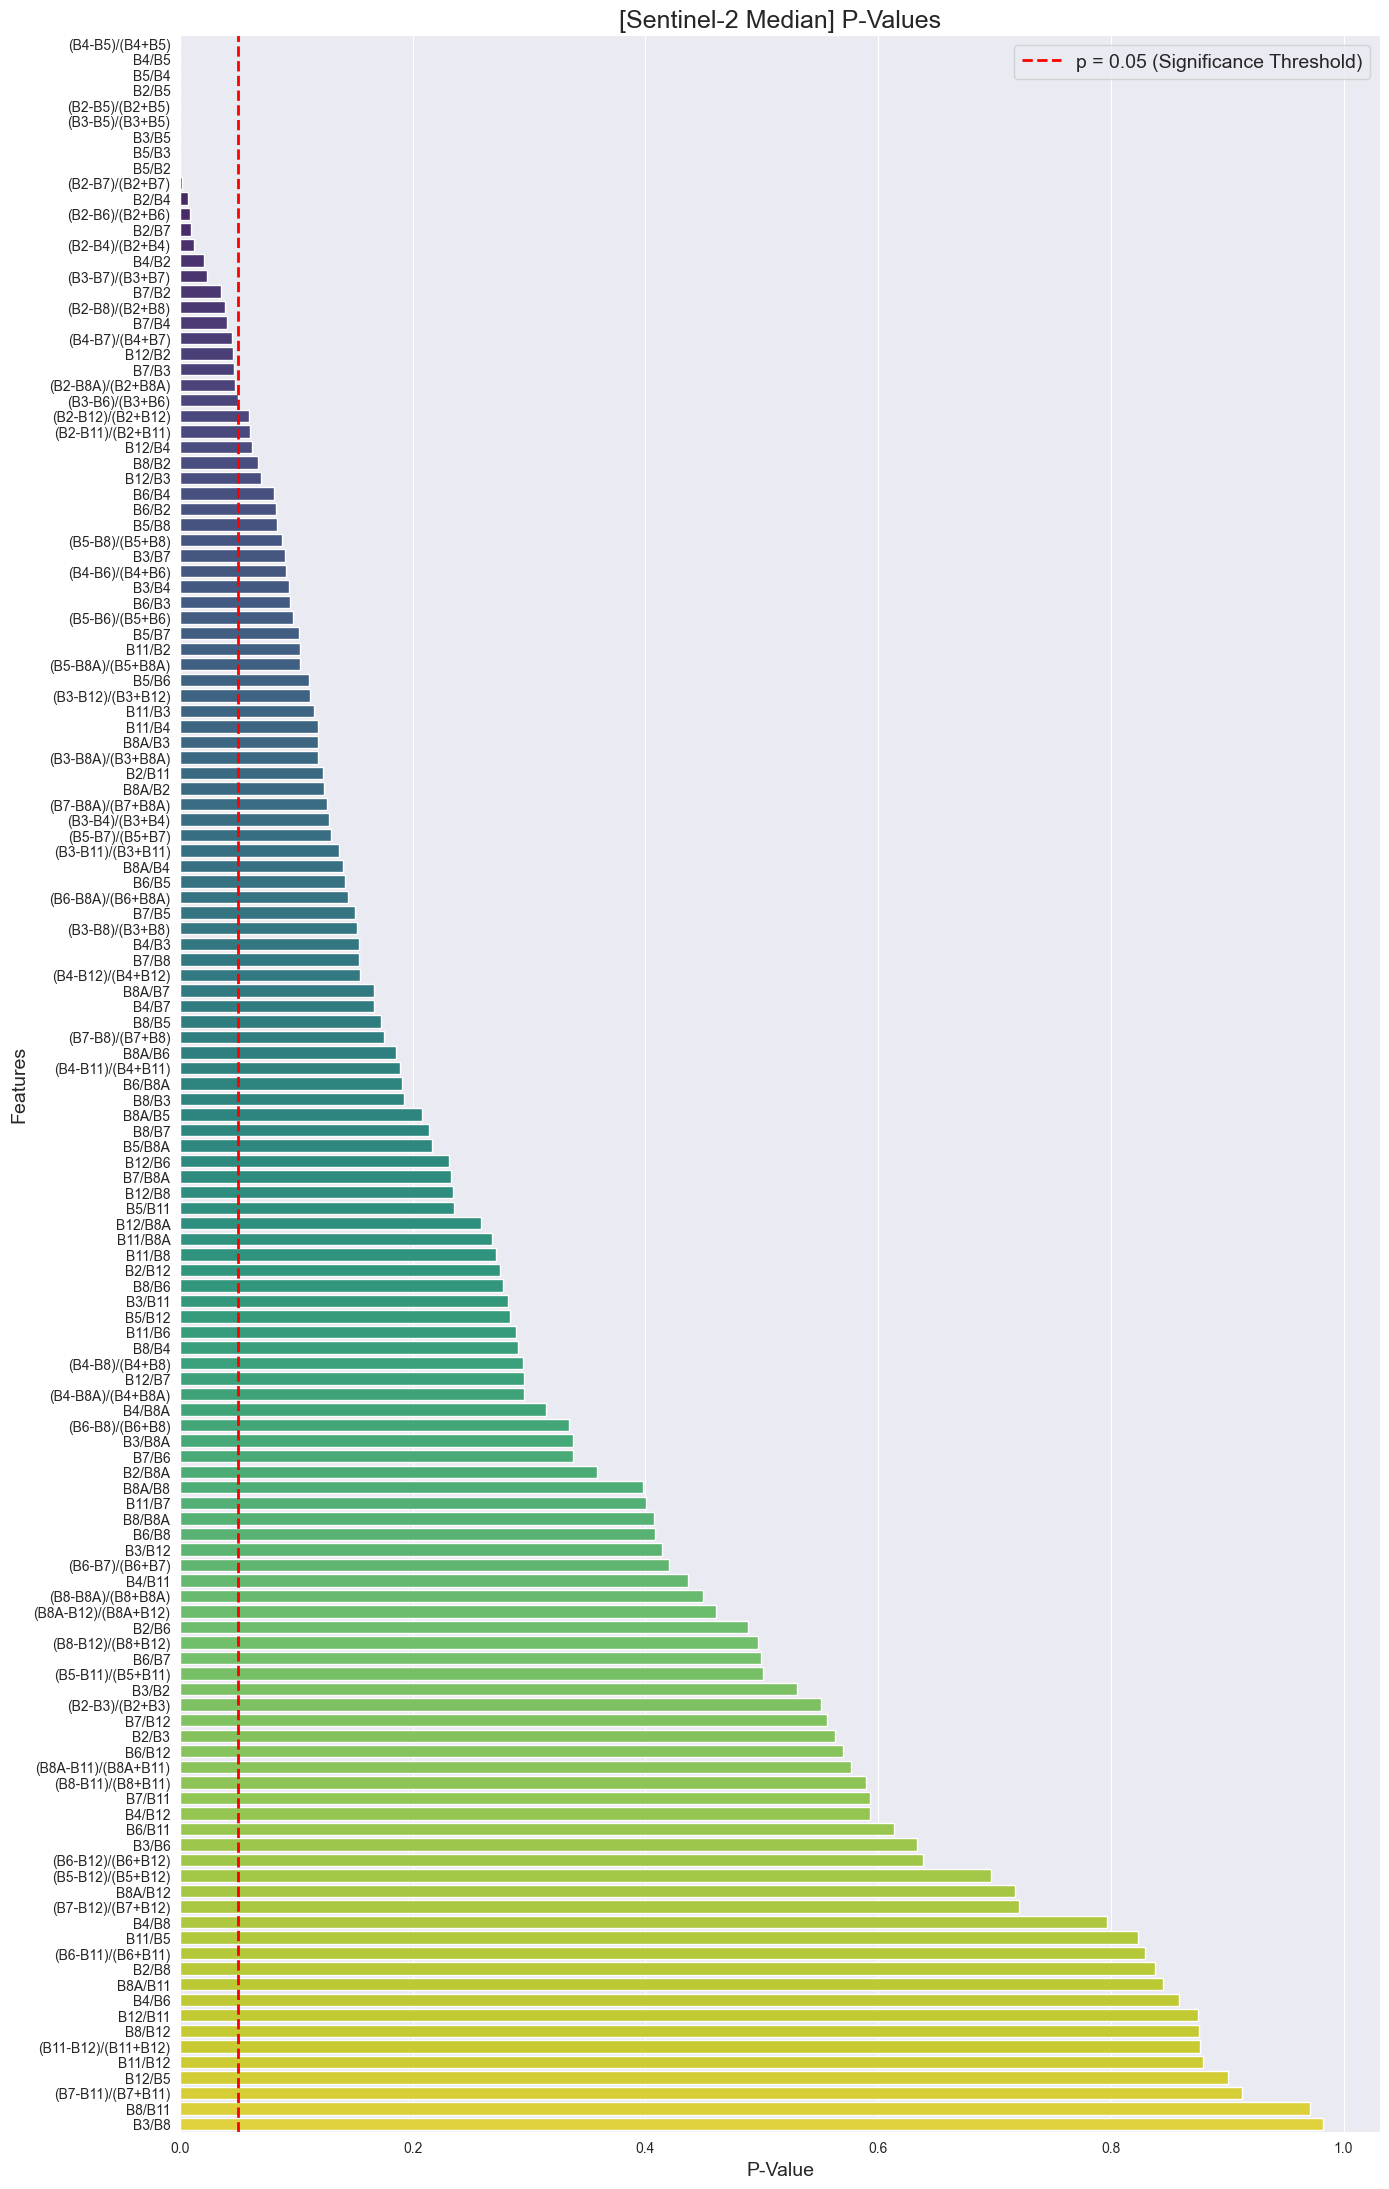

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Load Data ---
file_path = "Sentinel2_2024_Combinations(Median_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
y = data[target_col]

# --- 3. Calculate Regression Metrics ---
results = []
for col in feature_cols:
    X = data[col]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    results.append({
        'Feature': col,
        'R2_Score': model.rsquared,
        'P_Value': model.pvalues[col],
        'Coefficient': model.params[col]
    })

results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("    [Median] Complete Regression Metrics (Sorted by R2)   ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting ---

# Plot 1: R2 Score
plt.figure(figsize=(14, 22))
sns.barplot(x='R2_Score', y='Feature', data=results_df, palette='magma', hue='Feature', legend=False)
plt.title('[Sentinel-2 Median] Linear Regression R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: P-Values
plt.figure(figsize=(14, 22))
pval_sorted = results_df.sort_values(by='P_Value', ascending=True)
sns.barplot(x='P_Value', y='Feature', data=pval_sorted, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (Significance Threshold)')
plt.title('[Sentinel-2 Median] P-Values', fontsize=18)
plt.xlabel('P-Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Export to Excel
results_df.to_excel("Sentinel_Median_Regression_Results.xlsx", index=False)

      [SD] Complete Regression Metrics (Sorted by R2)     
        Feature  R2_Score  P_Value  Coefficient
          B4/B3  0.029938 0.178675    -5.630160
(B3-B4)/(B3+B4)  0.022996 0.239369     7.920253
          B4/B2  0.021536 0.255042    -4.190957
          B3/B8  0.019378 0.280560     1.177253
          B2/B3  0.014044 0.358940    -2.897149
          B2/B8  0.013806 0.363087     0.966563
          B8/B2  0.013169 0.374463    -1.383838
(B3-B8)/(B3+B8)  0.012543 0.386146     2.804716
          B8/B3  0.012398 0.388921    -1.276374
(B2-B4)/(B2+B4)  0.009578 0.449211     4.551909
          B3/B4  0.009355 0.454547     1.444470
(B2-B8)/(B2+B8)  0.008227 0.483242     2.363505
          B4/B8  0.007440 0.505026     1.106803
(B4-B8)/(B4+B8)  0.002985 0.673212     1.599346
          B8/B4  0.002441 0.702972    -0.493287
(B2-B3)/(B2+B3)  0.002344 0.708614    -2.901684
          B2/B4  0.000950 0.812018     0.458579
          B3/B2  0.000151 0.924599    -0.391986




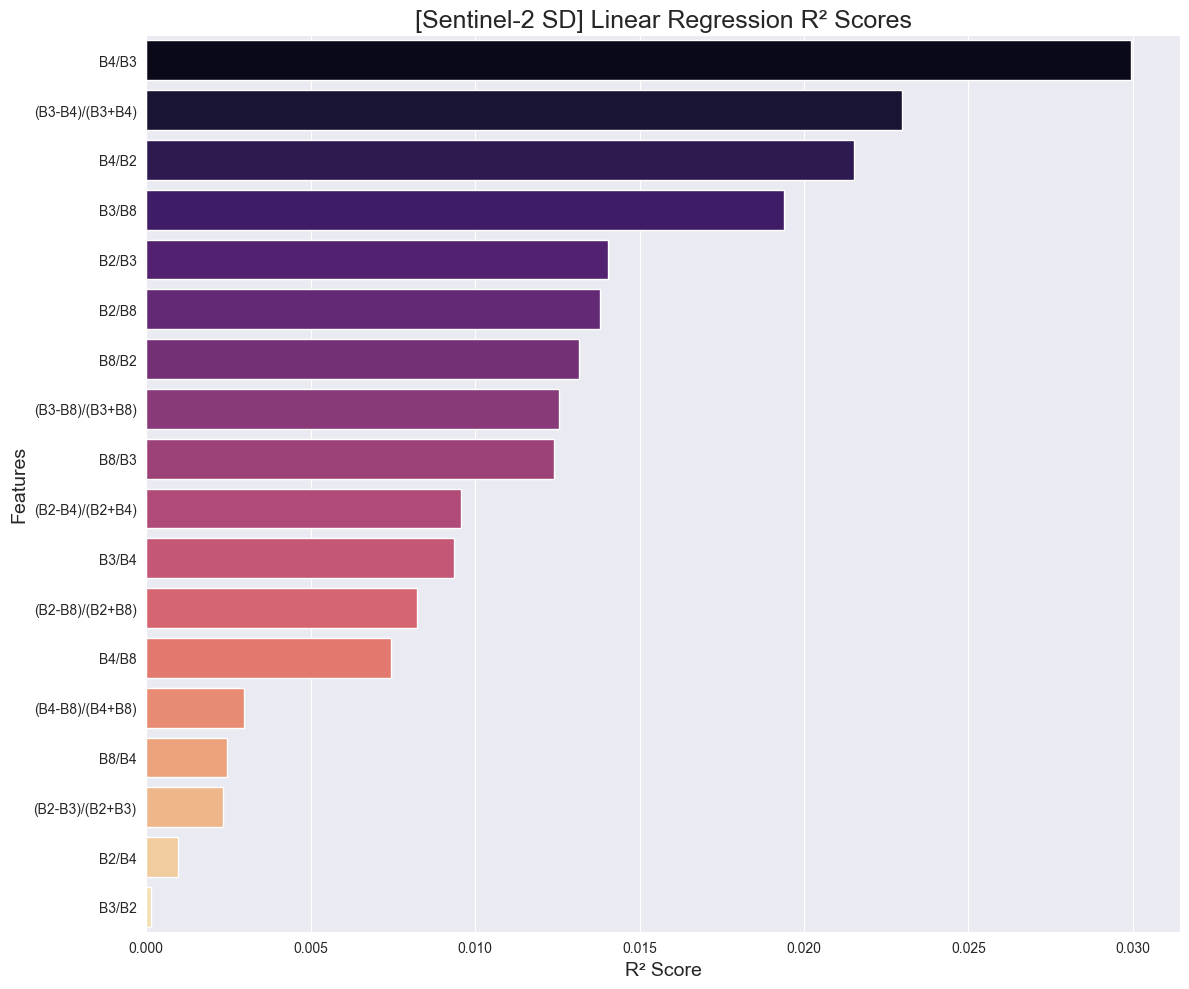

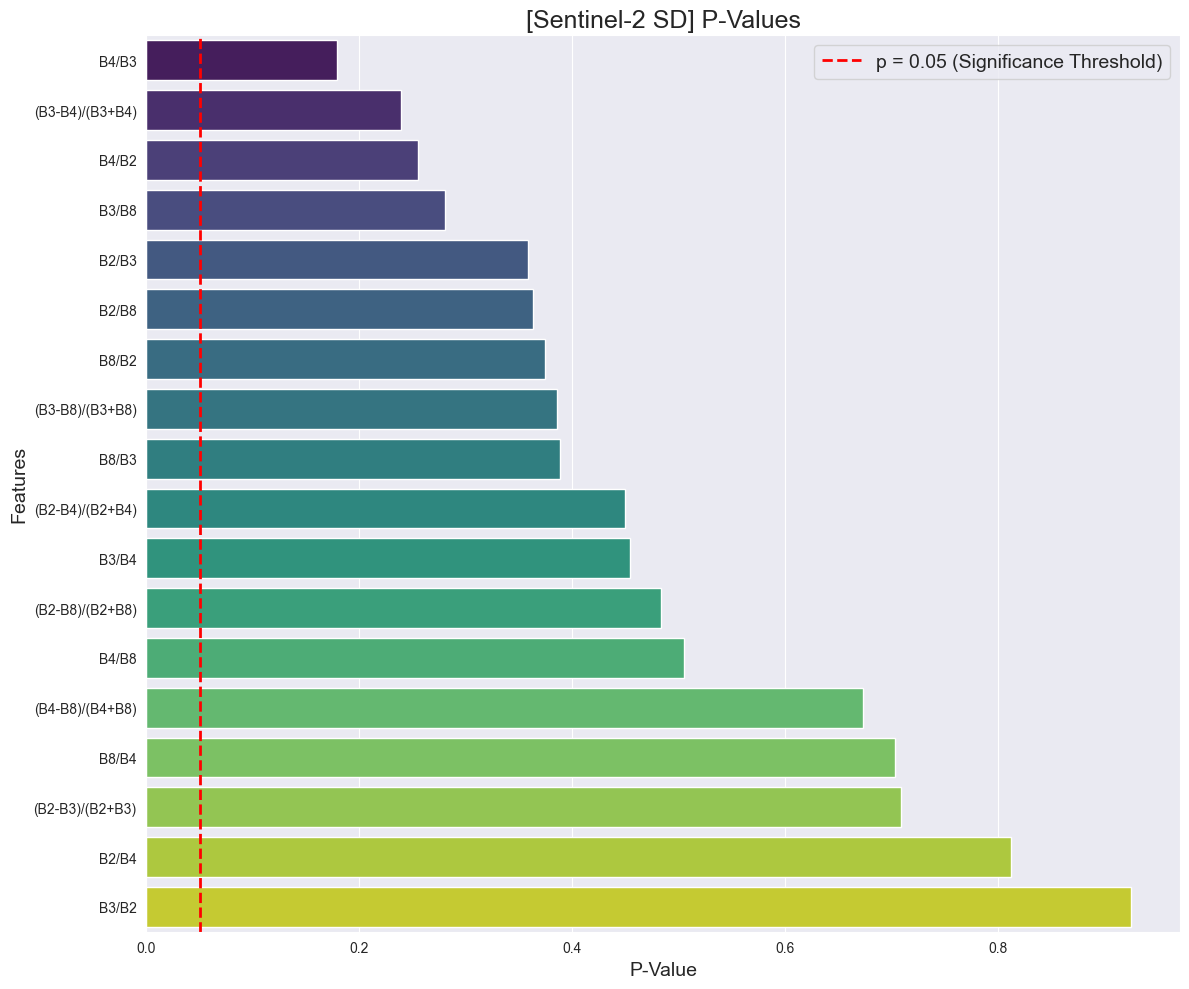

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Load Data ---
file_path = "Sentinel2_2024_Combinations(SD_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
y = data[target_col]

# --- 3. Calculate Regression Metrics ---
results = []
for col in feature_cols:
    X = data[col]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    results.append({
        'Feature': col,
        'R2_Score': model.rsquared,
        'P_Value': model.pvalues[col],
        'Coefficient': model.params[col]
    })

results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("      [SD] Complete Regression Metrics (Sorted by R2)     ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting ---

# Plot 1: R2 Score (Shorter figure for fewer features)
plt.figure(figsize=(12, 10))
sns.barplot(x='R2_Score', y='Feature', data=results_df, palette='magma', hue='Feature', legend=False)
plt.title('[Sentinel-2 SD] Linear Regression R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: P-Values
plt.figure(figsize=(12, 10))
pval_sorted = results_df.sort_values(by='P_Value', ascending=True)
sns.barplot(x='P_Value', y='Feature', data=pval_sorted, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (Significance Threshold)')
plt.title('[Sentinel-2 SD] P-Values', fontsize=18)
plt.xlabel('P-Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Export to Excel
results_df.to_excel("Sentinel_SD_Regression_Results.xlsx", index=False)

     [Mean] Complete Regression Metrics (Sorted by R2)    
        Feature  R2_Score      P_Value  B1_Coefficient  B0_Y_Intercept
          B4/B5  0.518654 2.876222e-11      -29.005173       37.392845
(B4-B5)/(B4+B5)  0.512312 4.312398e-11      -52.190751        8.119935
          B5/B4  0.499432 9.665425e-11       22.371433      -14.420824
          B2/B5  0.454117 1.420742e-09      -14.421551       27.449499
(B2-B5)/(B2+B5)  0.437476 3.612934e-09      -32.633550       12.473983
(B3-B5)/(B3+B5)  0.434671 4.217312e-09      -35.888184       18.020037
          B5/B3  0.432319 4.798828e-09       25.192577       -6.405527
          B3/B5  0.419873 9.426057e-09      -10.320133       27.104362
          B5/B2  0.401321 2.514268e-08       16.213931       -4.294955
(B2-B7)/(B2+B7)  0.168902 8.202699e-04      -17.931643       16.374563
(B2-B6)/(B2+B6)  0.132174 3.402702e-03      -15.141692       16.117860
          B2/B4  0.131196 3.532545e-03      -14.298635       29.335236
(B2-B4)/(B2+B4)  0

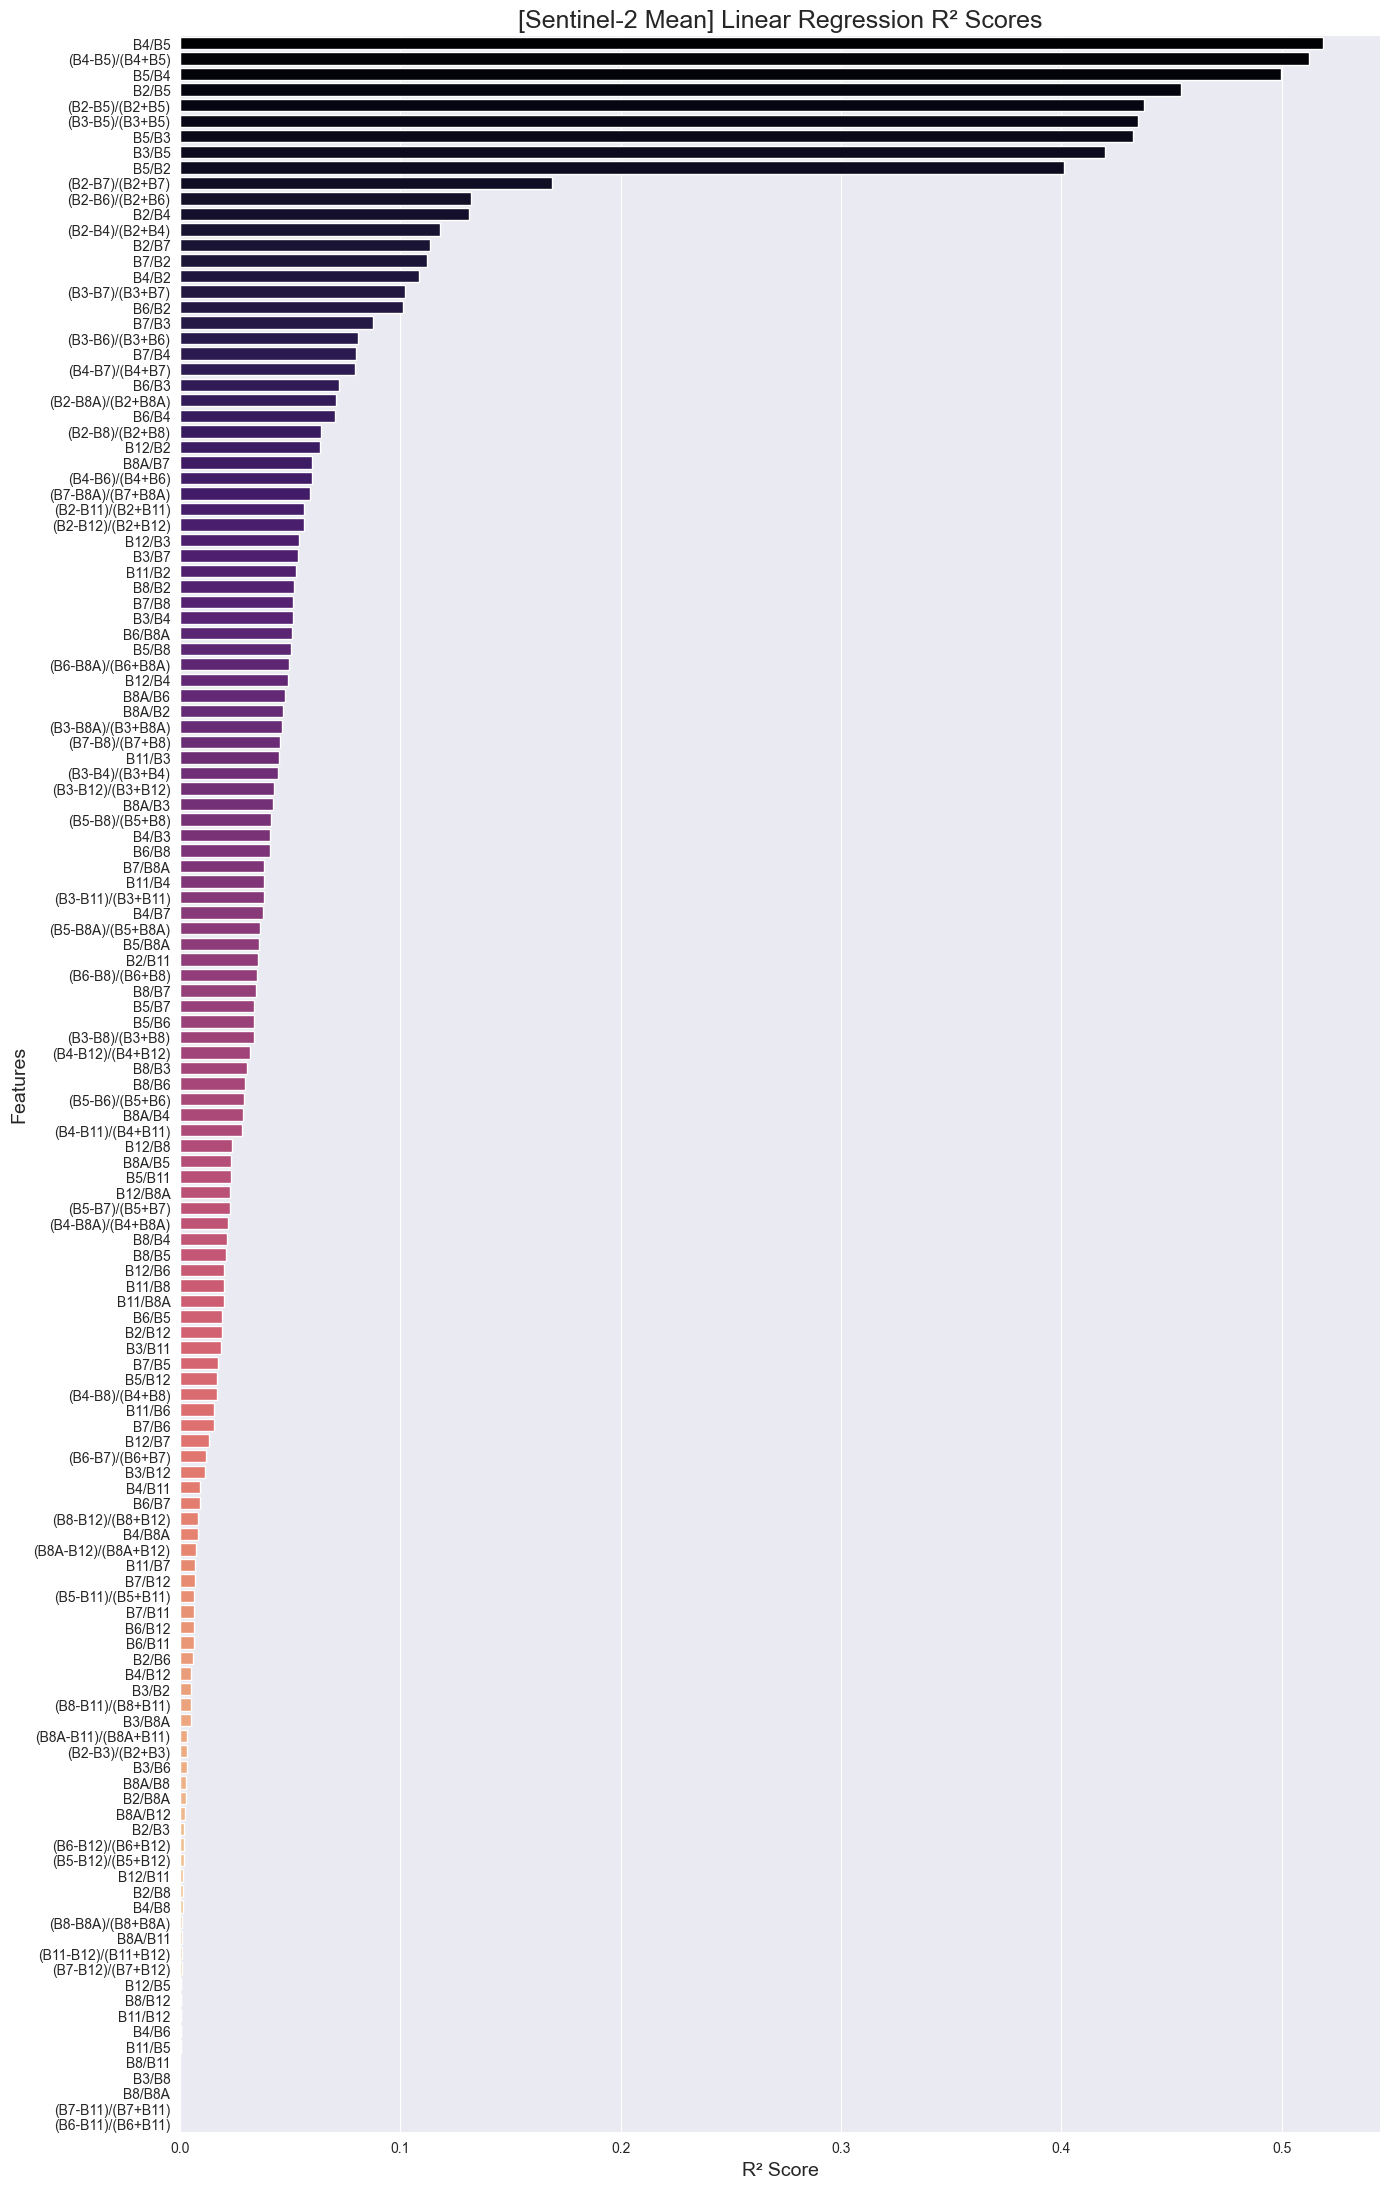

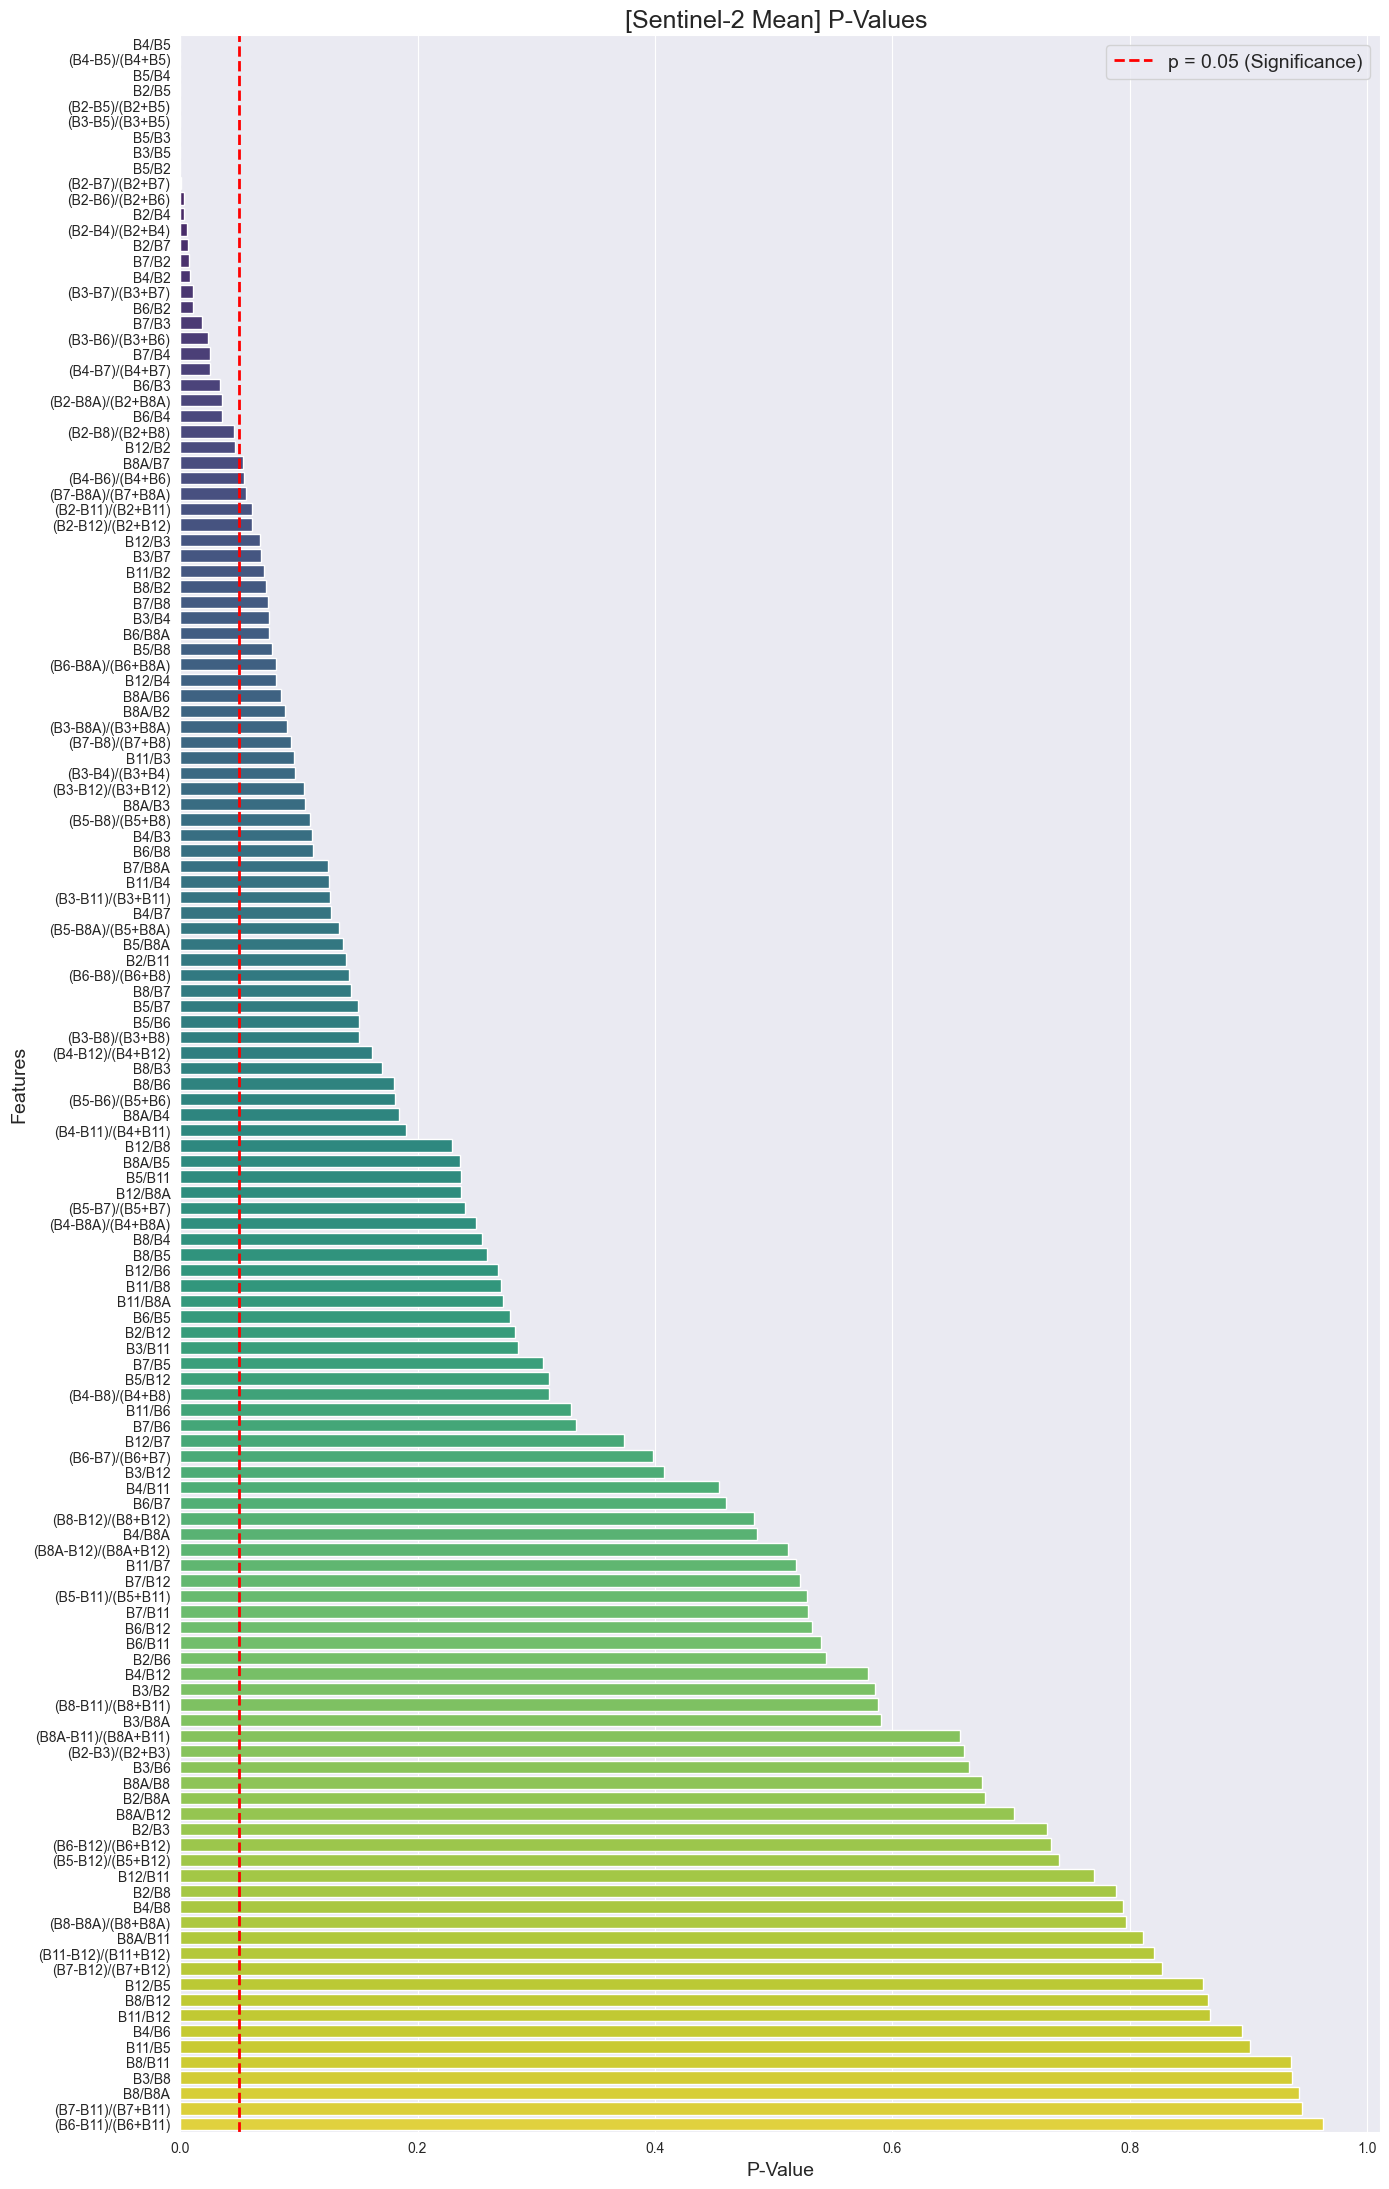

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Load Data ---
file_path = "Sentinel2_2024_Combinations(Mean_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
y = data[target_col]

# --- 3. Calculate Regression Metrics ---
results = []
for col in feature_cols:
    X = data[col]
    X = sm.add_constant(X) # This adds the y-intercept
    model = sm.OLS(y, X).fit()

    results.append({
        'Feature': col,
        'R2_Score': model.rsquared,
        'P_Value': model.pvalues[col],
        'B1_Coefficient': model.params[col],    # The multiplier for the feature
        'B0_Y_Intercept': model.params['const'] # The starting constant
    })

results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("     [Mean] Complete Regression Metrics (Sorted by R2)    ")
print("==========================================================")
print(results_df.head(15).to_string(index=False)) # Printing top 15 for a clean view
print("\n")

# --- 4. Plotting ---

# Plot 1: R2 Score
plt.figure(figsize=(14, 22))
sns.barplot(x='R2_Score', y='Feature', data=results_df, palette='magma', hue='Feature', legend=False)
plt.title('[Sentinel-2 Mean] Linear Regression R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: P-Values
plt.figure(figsize=(14, 22))
pval_sorted = results_df.sort_values(by='P_Value', ascending=True)
sns.barplot(x='P_Value', y='Feature', data=pval_sorted, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (Significance)')
plt.title('[Sentinel-2 Mean] P-Values ', fontsize=18)
plt.xlabel('P-Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Export to Excel
results_df.to_excel("Sentinel_Mean_Regression_Results.xlsx", index=False)